# ERA5 vs GSOD Validation — Khulna Heat-Stress Study

Validates ERA5 reanalysis against observed NOAA **GSOD** station data for the GeoHealth submission (Sakib & Khandaker). Run cells top to bottom; requires an open internet connection (NCEI + Open-Meteo).

```bash
pip install requests pandas numpy matplotlib
```

**Caveats:** GSOD reports daily *mean* temperature and dewpoint, so RH is *derived* (no RH field in GSOD). ERA5 is a 0.25° grid-cell average vs a point station — some disagreement is expected and is exactly what this quantifies. Confirm the station name printed below contains **KHULNA**. Bangladeshi GSOD coverage is often patchy; if the matched *n* is small, report the validation as *indicative*.

In [ ]:
import io, time
import numpy as np
import pandas as pd
import requests

STATION_ID  = "41947099999"        # Khulna (NCEI GSOD)
LAT, LON    = 22.8098, 89.5644     # matches manuscript fetch point
START_YEAR  = 2000
END_YEAR    = 2025
MAKE_FIGURE = True

GSOD_URL = "https://www.ncei.noaa.gov/data/global-summary-of-the-day/access/{year}/{sid}.csv"
ERA5_URL = "https://archive-api.open-meteo.com/v1/archive"

## 1 · Download GSOD station data

In [ ]:
frames = []
name_seen = None
for year in range(START_YEAR, END_YEAR + 1):
    url = GSOD_URL.format(year=year, sid=STATION_ID)
    try:
        r = requests.get(url, timeout=60)
    except requests.RequestException as exc:
        print(f"  [GSOD {year}] request failed: {exc}")
        continue
    if r.status_code != 200:
        print(f"  [GSOD {year}] HTTP {r.status_code} - skipping")
        continue
    df_year = pd.read_csv(io.StringIO(r.text))
    if name_seen is None and "NAME" in df_year.columns and len(df_year):
        name_seen = str(df_year["NAME"].iloc[0])
    frames.append(df_year)
    print(f"  [GSOD {year}] {len(df_year)} rows")
    time.sleep(0.3)   # be polite to NCEI

assert frames, "No GSOD data downloaded - check station ID / network."
raw = pd.concat(frames, ignore_index=True)
print(f"\nGSOD station name reported by NCEI: {name_seen!r}")
if name_seen and "KHULNA" not in name_seen.upper():
    print("*** WARNING: station name has no 'KHULNA' - verify STATION_ID. ***")
print(f"Total raw GSOD rows: {len(raw)}")

  [GSOD 2000] HTTP 404 - skipping
  [GSOD 2001] HTTP 404 - skipping
  [GSOD 2002] HTTP 404 - skipping
  [GSOD 2003] HTTP 404 - skipping
  [GSOD 2004] HTTP 404 - skipping
  [GSOD 2005] HTTP 404 - skipping
  [GSOD 2006] HTTP 404 - skipping
  [GSOD 2007] HTTP 404 - skipping
  [GSOD 2008] HTTP 404 - skipping
  [GSOD 2009] HTTP 404 - skipping
  [GSOD 2010] HTTP 404 - skipping
  [GSOD 2011] 122 rows
  [GSOD 2012] 202 rows
  [GSOD 2013] 245 rows
  [GSOD 2014] 331 rows
  [GSOD 2015] 337 rows
  [GSOD 2016] 329 rows
  [GSOD 2017] 342 rows
  [GSOD 2018] 300 rows
  [GSOD 2019] 195 rows
  [GSOD 2020] 317 rows
  [GSOD 2021] 25 rows
  [GSOD 2022] 68 rows
  [GSOD 2023] 301 rows
  [GSOD 2024] 331 rows
  [GSOD 2025] 235 rows

GSOD station name reported by NCEI: 'KHULNA, BG'
Total raw GSOD rows: 3680


## 2 · GSOD → daily T, RH, $T_w$, WBGT (inline formulas)

In [ ]:
gsod = pd.DataFrame()
gsod["date"] = pd.to_datetime(raw["DATE"])

# GSOD temps are Fahrenheit; missing code 9999.9 -> NaN
temp_f = pd.to_numeric(raw["TEMP"], errors="coerce").where(lambda s: s < 9000)
dewp_f = pd.to_numeric(raw["DEWP"], errors="coerce").where(lambda s: s < 9000)

gsod["T_obs"] = (temp_f - 32.0) * 5.0 / 9.0      # daily mean temperature, degC
Td_obs        = (dewp_f - 32.0) * 5.0 / 9.0      # daily mean dewpoint, degC

# RH (%) from T and Td via saturation vapour pressure (manuscript es formula)
es_T_obs  = 6.112 * np.exp(17.67 * gsod["T_obs"] / (gsod["T_obs"] + 243.5))
es_Td_obs = 6.112 * np.exp(17.67 * Td_obs        / (Td_obs        + 243.5))
gsod["RH_obs"] = (100.0 * es_Td_obs / es_T_obs).clip(0, 100)

gsod = gsod.dropna(subset=["T_obs", "RH_obs"]).reset_index(drop=True)

T, RH = gsod["T_obs"], gsod["RH_obs"]
# Wet-bulb temperature — Stull (2011); arctan in radians
gsod["Tw_obs"] = (T * np.arctan(0.151977 * (RH + 8.313659) ** 0.5)
                  + np.arctan(T + RH) - np.arctan(RH - 1.676331)
                  + 0.00391838 * RH ** 1.5 * np.arctan(0.023101 * RH)
                  - 4.686035)
# WBGT indoor/shaded — Bernard & Pourmoghani (1999)
e_obs = (RH / 100.0) * 6.112 * np.exp(17.67 * T / (T + 243.5))
gsod["WBGT_obs"] = 0.567 * T + 0.393 * e_obs + 3.94

print(f"GSOD usable daily records: {len(gsod)}")
gsod.head()

GSOD usable daily records: 3669


,date,T_obs,RH_obs,Tw_obs,WBGT_obs
0,2011-06-29,28.555556,91.306461,27.384733,34.144795
1,2011-06-30,29.222222,88.998349,27.707614,34.706968
2,2011-07-01,28.277778,91.588700,27.150640,33.805214
3,2011-07-02,27.111111,93.040306,26.200630,32.435911
4,2011-07-04,28.166667,88.044263,26.533582,33.121117


## 3 · Download ERA5 and compute the same indices

In [ ]:
params = {
    "latitude": LAT, "longitude": LON,
    "start_date": f"{START_YEAR}-01-01", "end_date": f"{END_YEAR}-12-31",
    "daily": "temperature_2m_mean,relative_humidity_2m_mean",
    "timezone": "auto",
}
resp = requests.get(ERA5_URL, params=params, timeout=120)
resp.raise_for_status()
d = resp.json()["daily"]

era = pd.DataFrame({
    "date":   pd.to_datetime(d["time"]),
    "T_era":  pd.to_numeric(d["temperature_2m_mean"], errors="coerce"),
    "RH_era": pd.to_numeric(d["relative_humidity_2m_mean"], errors="coerce"),
}).dropna().reset_index(drop=True)

Te, RHe = era["T_era"], era["RH_era"]
era["Tw_era"] = (Te * np.arctan(0.151977 * (RHe + 8.313659) ** 0.5)
                 + np.arctan(Te + RHe) - np.arctan(RHe - 1.676331)
                 + 0.00391838 * RHe ** 1.5 * np.arctan(0.023101 * RHe)
                 - 4.686035)
e_era = (RHe / 100.0) * 6.112 * np.exp(17.67 * Te / (Te + 243.5))
era["WBGT_era"] = 0.567 * Te + 0.393 * e_era + 3.94

print(f"ERA5 daily records: {len(era)}")
era.head()

ERA5 daily records: 9497


,date,T_era,RH_era,Tw_era,WBGT_era
0,2000-01-01,18.9,64,14.517832,20.145300
1,2000-01-02,18.8,68,14.917789,20.395318
2,2000-01-03,18.7,70,15.069077,20.471872
3,2000-01-04,18.4,70,14.789606,20.191366
4,2000-01-05,17.9,70,14.323819,19.727865


## 4 · Match day-by-day

In [ ]:
merged = pd.merge(gsod, era, on="date", how="inner").sort_values("date").reset_index(drop=True)
n_match = len(merged)
print(f"Matched daily records (GSOD AND ERA5): {n_match}")
if n_match:
    print(f"Matched date span: {merged['date'].min().date()} to {merged['date'].max().date()}")
    full_days = (pd.Timestamp(f'{END_YEAR}-12-31') - pd.Timestamp(f'{START_YEAR}-01-01')).days
    print(f"Coverage vs full period: {100.0 * n_match / full_days:.1f}%")
merged.to_csv("validation_matched_daily.csv", index=False)

Matched daily records (GSOD AND ERA5): 3669
Matched date span: 2011-06-29 to 2025-08-24
Coverage vs full period: 38.6%


## 5 · Daily validation statistics

`MBE = mean(ERA5 − GSOD)`; positive = ERA5 warmer/wetter than the station.

In [ ]:
pairs = [
    ("Mean T (degC)", "T_obs",    "T_era"),
    ("RH (%)",        "RH_obs",   "RH_era"),
    ("Tw (degC)",     "Tw_obs",   "Tw_era"),
    ("WBGT (degC)",   "WBGT_obs", "WBGT_era"),
]
rows = []
for label, oc, mc in pairs:
    o = merged[oc].to_numpy(float); m = merged[mc].to_numpy(float)
    keep = np.isfinite(o) & np.isfinite(m)
    o, m = o[keep], m[keep]
    diff = m - o
    rows.append({
        "variable": label,
        "n": len(o),
        "MBE":  float(np.mean(diff)),
        "RMSE": float(np.sqrt(np.mean(diff ** 2))),
        "MAE":  float(np.mean(np.abs(diff))),
        "r":    float(np.corrcoef(o, m)[0, 1]) if len(o) > 1 else np.nan,
    })
res = pd.DataFrame(rows)[["variable", "n", "MBE", "RMSE", "MAE", "r"]]
res.to_csv("validation_results.csv", index=False)
print(res.to_string(index=False,
      formatters={"MBE": "{:+.3f}".format, "RMSE": "{:.3f}".format,
                  "MAE": "{:.3f}".format, "r": "{:.3f}".format}))
res

     variable    n    MBE  RMSE   MAE     r
Mean T (degC) 3669 -0.833 1.354 1.137 0.974
       RH (%) 3669 -0.129 6.017 4.673 0.778
    Tw (degC) 3669 -0.791 1.139 0.965 0.983
  WBGT (degC) 3669 -1.023 1.460 1.232 0.982


,variable,n,MBE,RMSE,MAE,r
0,Mean T (degC),3669,-0.833279,1.353995,1.137449,0.974249
1,RH (%),3669,-0.128834,6.016545,4.672690,0.778473
2,Tw (degC),3669,-0.790528,1.138557,0.965424,0.983203
3,WBGT (degC),3669,-1.023234,1.459832,1.232375,0.982268


## 6 · Annual-mean agreement

This is the scale the Mann-Kendall trend test actually operates on.

In [ ]:
ann = (merged.assign(year=merged["date"].dt.year)
             .groupby("year")[["WBGT_obs", "WBGT_era", "Tw_obs", "Tw_era"]].mean())
for v in ["WBGT", "Tw"]:
    o = ann[f"{v}_obs"].to_numpy(float); m = ann[f"{v}_era"].to_numpy(float)
    diff = m - o
    r = float(np.corrcoef(o, m)[0, 1]) if len(o) > 1 else np.nan
    print(f"{v:5s}: years={len(o):2d}  MBE={np.mean(diff):+.3f}  "
          f"RMSE={np.sqrt(np.mean(diff ** 2)):.3f}  r={r:.3f}")
ann

WBGT : years=15  MBE=-1.014  RMSE=1.065  r=0.990
Tw   : years=15  MBE=-0.812  RMSE=0.864  r=0.986


,WBGT_obs,WBGT_era,Tw_obs,Tw_era
year,,,,
2011,30.455700,29.172156,24.161255,23.126350
2012,30.027201,28.519920,23.632528,22.317406
2013,30.127838,28.656284,23.767003,22.512530
2014,30.051964,29.162820,23.557655,22.884776
2015,30.337808,29.311825,23.937616,23.122472
2016,30.164022,29.276478,23.775217,23.096659
2017,29.790751,28.966967,23.436892,22.813764
2018,30.176827,29.409479,23.687301,23.172207
2019,30.264491,29.298376,23.896072,23.160703


## 7 · Scatter plot (ERA5 vs GSOD, 1:1 line)

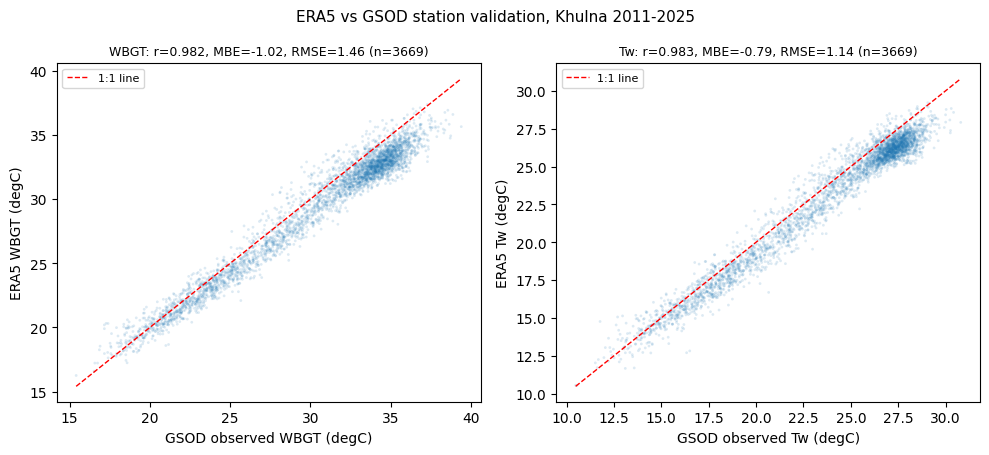

Saved Fig_validation.png


In [ ]:
if MAKE_FIGURE and n_match:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
    for a, v, ttl in [(ax[0], "WBGT", "WBGT (degC)"), (ax[1], "Tw", "Tw (degC)")]:
        x = merged[f"{v}_obs"]; y = merged[f"{v}_era"]
        a.scatter(x, y, s=4, alpha=0.15, edgecolor="none")
        lo = float(min(x.min(), y.min())); hi = float(max(x.max(), y.max()))
        a.plot([lo, hi], [lo, hi], "r--", lw=1, label="1:1 line")
        diff = (y - x).to_numpy(float)
        rr = float(np.corrcoef(x, y)[0, 1])
        a.set_xlabel(f"GSOD observed {ttl}")
        a.set_ylabel(f"ERA5 {ttl}")
        a.set_title(f"{v}: r={rr:.3f}, MBE={np.mean(diff):+.2f}, "
                    f"RMSE={np.sqrt(np.mean(diff ** 2)):.2f} (n={len(x)})", fontsize=9)
        a.legend(fontsize=8)
    fig.suptitle("ERA5 vs GSOD station validation, Khulna 2011-2025", fontsize=11)
    fig.tight_layout()
    fig.savefig("Fig_validation.png", dpi=300)
    plt.show()
    print("Saved Fig_validation.png")